<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Finding Missing Values**


Estimated time needed: **30** minutes


Data wrangling is the process of cleaning, transforming, and organizing data to make it suitable for analysis. Finding and handling missing values is a crucial step in this process to ensure data accuracy and completeness. In this lab, you will focus exclusively on identifying and handling missing values in the dataset.


## Objectives


After completing this lab, you will be able to:


-   Identify missing values in the dataset.

- Quantify missing values for specific columns.

- Impute missing values using various strategies.


## Hands on Lab


##### Setup: Install Required Libraries


In [1]:
!pip install pandas
!pip install matplotlib
!pip install seaborn

##### Import Necessary Modules:


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Tasks


<h2>1. Load the Dataset</h2>
code
#VSC-619bdff2
python
# Basic information and summary statistics
print('DataFrame info:')
df.info()
print('\nSummary statistics (numeric):')
print(df.describe(include='number').transpose())
print('\nSummary statistics (object):')
print(df.describe(include='object').transpose())

code
#VSC-cbebc7b1
python
# Load dataset: try remote, fallback to local file
remote_url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/UDKAZw-kz18Yj8P6icf_qw/survey-data-duplicates.csv"
local_file = 'survey-data-duplicates.csv'
import os
try:
    df = pd.read_csv(remote_url)
    print('Loaded remote dataset')
except Exception as e:
    print(f'Could not load remote dataset ({e}). Using local file: {local_file}')
    df = pd.read_csv(local_file)

print('\nFirst 5 rows:')
print(df.head())
print('\nDataset shape:', df.shape)

markdown
#VSC-8cc13cad
markdown
### 2. Explore the Dataset
##### Task 1: Display basic information and summary statistics of the dataset.

code
#VSC-619bdff2
python
# Basic information and summary statistics
print('DataFrame info:')
print(df.info())
print('




print(df.describe(include='object').transpose())print('
Summary statistics (object):')print(df.describe(include='number').transpose())Summary statistics (numeric):')
markdown
#VSC-1e9865c9
markdown
### 3. Finding Missing Values
##### Task 2: Identify missing values for all columns.

code
#VSC-936031cc
python
# Identify missing values for all columns
missing_counts = df.isna().sum()
print('Missing values by column:')
print(missing_counts[missing_counts > 0].sort_values(ascending=False))
print('\nTotal missing values:', missing_counts.sum())

markdown
#VSC-1867de0b
markdown
##### Task 3: Visualize missing values using a heatmap (Using seaborn library).


code
#VSC-a003f38a
python
# Visualize missing values heatmap (sample columns to avoid huge plot)
sample_cols = df.columns[:30] if df.shape[1] > 30 else df.columns
plt.figure(figsize=(12,6))
sns.heatmap(df[sample_cols].isna(), cbar=False)
plt.title('Missing values heatmap (sampled columns)')
plt.show()

markdown
#VSC-b0448594
markdown
##### Task 4: Count the number of missing rows for a specific column (e.g., `Employment`).

code
#VSC-babf477a
python
# Count missing rows for the 'Employment' column
if 'Employment' in df.columns:
    missing_employment = df['Employment'].isna().sum()
    print('Missing values in Employment:', missing_employment)
else:
    print('Employment column not found')

markdown
#VSC-32eb0760
markdown
### 4. Imputing Missing Values
##### Task 5: Identify the most frequent (majority) value in a specific column (e.g., `Employment`).

code
#VSC-14dd399f
python
# Identify the most frequent value in Employment
if 'Employment' in df.columns:
    mode_emp = df['Employment'].mode(dropna=True)
    if not mode_emp.empty:
        print('Most frequent Employment value:', mode_emp.iloc[0])
    else:
        print('No mode found for Employment')
else:
    print('Employment column not found')

markdown
#VSC-97707c41
markdown
##### Task 6: Impute missing values in the `Employment` column with the most frequent value.


code
#VSC-3292a1af
python
# Impute missing Employment with mode
df_imputed = df.copy()
if 'Employment' in df_imputed.columns:
    mode_emp = df_imputed['Employment'].mode(dropna=True)
    if not mode_emp.empty:
        df_imputed['Employment'] = df_imputed['Employment'].fillna(mode_emp.iloc[0])
        print('Imputed Employment with mode:', mode_emp.iloc[0])
    else:
        print('No mode to impute Employment')
else:
    print('Employment column not found')

print('Missing Employment after imputation:', df_imputed['Employment'].isna().sum() if 'Employment' in df_imputed.columns else 'N/A')

markdown
#VSC-7eee17f7
markdown
### 5. Visualizing Imputed Data
##### Task 7: Visualize the distribution of a column after imputation (e.g., `Employment`).

code
#VSC-0ad154a4
python
# Visualize Employment distribution after imputation
if 'Employment' in df_imputed.columns:
    plt.figure(figsize=(8,4))
    sns.countplot(y='Employment', data=df_imputed, order=df_imputed['Employment'].value_counts().index)
    plt.title('Employment distribution after imputation')
    plt.tight_layout()
    plt.show()
else:
    print('Employment column not available for plotting')

markdown
#VSC-19120472
markdown
### Summary

markdown
#VSC-4310fc56
markdown
In this lab, you:
- Loaded the dataset into a pandas DataFrame.
- Identified missing values across all columns.
- Quantified missing values in specific columns.
- Imputed missing values in a categorical column using the most frequent value.
- Visualized the imputed data for better understanding.
  

markdown
#VSC-c1a582c8
markdown
Copyright © IBM Corporation. All rights reserved.



First 5 rows:
   ResponseId                      MainBranch                 Age  \
0           1  I am a developer by profession  Under 18 years old   
1           2  I am a developer by profession     35-44 years old   
2           3  I am a developer by profession     45-54 years old   
3           4           I am learning to code     18-24 years old   
4           5  I am a developer by profession     18-24 years old   

            Employment RemoteWork   Check  \
0  Employed, full-time     Remote  Apples   
1  Employed, full-time     Remote  Apples   
2  Employed, full-time     Remote  Apples   
3   Student, full-time        NaN  Apples   
4   Student, full-time        NaN  Apples   

                                    CodingActivities  \
0                                              Hobby   
1  Hobby;Contribute to open-source projects;Other...   
2  Hobby;Contribute to open-source projects;Other...   
3                                                NaN   
4                  

C:\Users\moham\AppData\Local\Temp\ipykernel_6372\524061267.py:29: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  print(df.describe(include='object').transpose())


                      count unique                                   top  \
MainBranch            65447      5        I am a developer by profession   
Age                   65447      8                       25-34 years old   
Employment            65447    110                   Employed, full-time   
RemoteWork            54812      3  Hybrid (some remote, some in-person)   
Check                 65447      1                                Apples   
...                     ...    ...                                   ...   
ProfessionalCloud     28491      3            Hybrid (on-prem and cloud)   
ProfessionalQuestion  28807      9      Traditional public search engine   
Industry              28858     15                  Software Development   
SurveyLength          56190      3                 Appropriate in length   
SurveyEase            56246      3                                  Easy   

                       freq  
MainBranch            50212  
Age                   23911

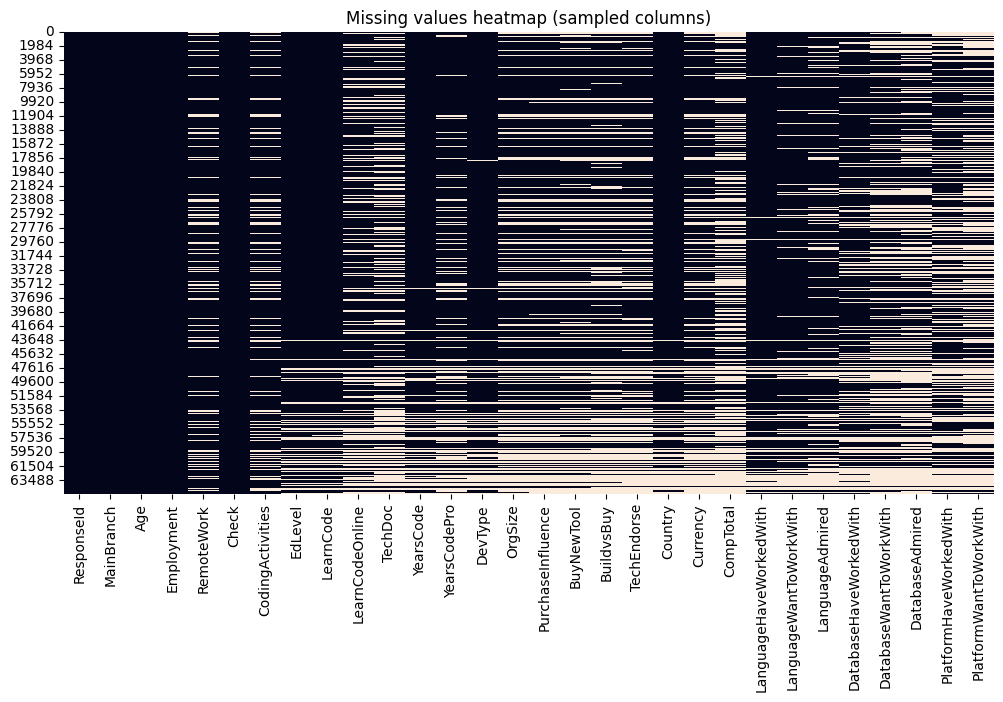


Missing values in Employment: 0

Imputed Employment with mode: Employed, full-time
Missing Employment after imputation: 0


C:\Users\moham\AppData\Local\Temp\ipykernel_6372\524061267.py:65: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


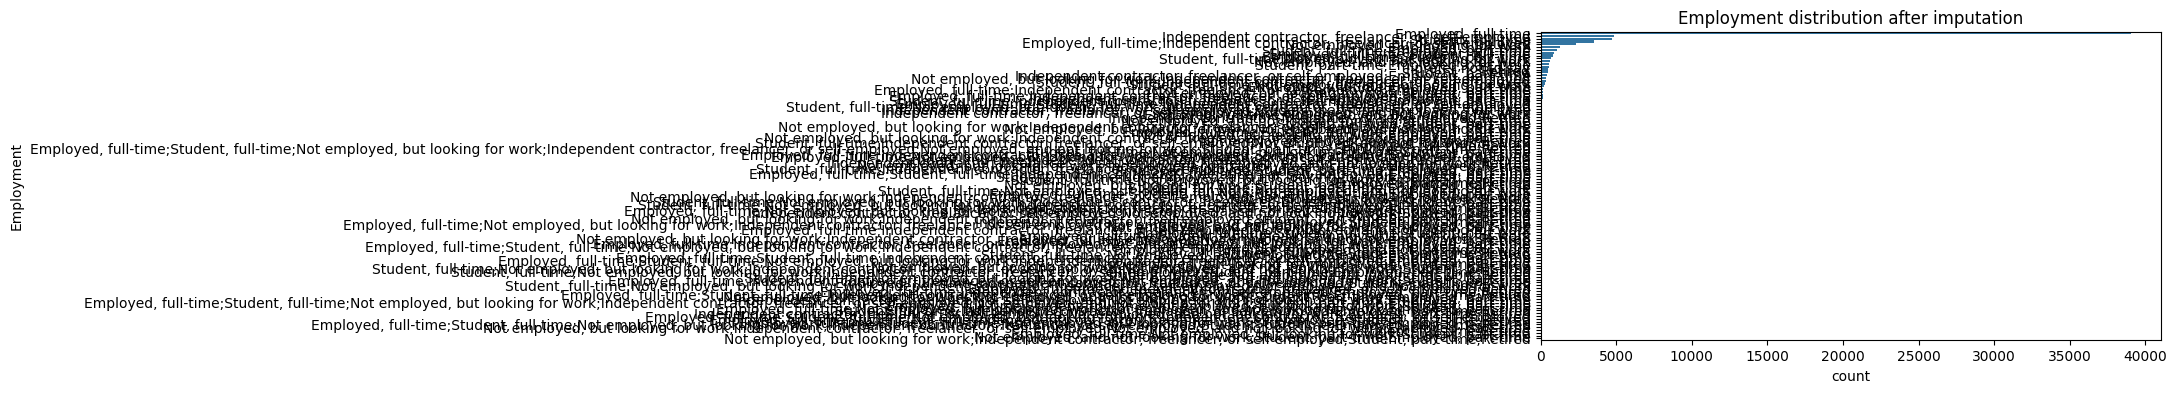

In [5]:
# Full analysis cell: missing values, imputation, and plots
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure df is available; if not, load from local
try:
    df
except NameError:
    remote_url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/UDKAZw-kz18Yj8P6icf_qw/survey-data-duplicates.csv"
    local_file = 'survey-data-duplicates.csv'
    try:
        df = pd.read_csv(remote_url)
        print('Loaded remote dataset')
    except Exception as e:
        print(f'Could not load remote dataset ({e}). Using local file: {local_file}')
        df = pd.read_csv(local_file)

print('\nFirst 5 rows:')
print(df.head())
print('\nDataset shape:', df.shape)

print('\nDataFrame info:')
df.info()

print('\nSummary statistics (numeric):')
print(df.describe(include='number').transpose())

print('\nSummary statistics (object):')
print(df.describe(include='object').transpose())

# Missing values
missing_counts = df.isna().sum()
print('\nMissing values by column:')
print(missing_counts[missing_counts > 0].sort_values(ascending=False))
print('\nTotal missing values:', missing_counts.sum())

# Heatmap
sample_cols = df.columns[:30] if df.shape[1] > 30 else df.columns
plt.figure(figsize=(12,6))
sns.heatmap(df[sample_cols].isna(), cbar=False)
plt.title('Missing values heatmap (sampled columns)')
plt.show()

# Missing Employment
if 'Employment' in df.columns:
    missing_employment = df['Employment'].isna().sum()
    print('\nMissing values in Employment:', missing_employment)
else:
    print('\nEmployment column not found')

# Impute Employment
if 'Employment' in df.columns:
    df_imputed = df.copy()
    mode_emp = df_imputed['Employment'].mode(dropna=True)
    if not mode_emp.empty:
        df_imputed['Employment'] = df_imputed['Employment'].fillna(mode_emp.iloc[0])
        print('\nImputed Employment with mode:', mode_emp.iloc[0])
    else:
        print('\nNo mode to impute Employment')
    print('Missing Employment after imputation:', df_imputed['Employment'].isna().sum())
    # Plot distribution
    plt.figure(figsize=(8,4))
    sns.countplot(y='Employment', data=df_imputed, order=df_imputed['Employment'].value_counts().index)
    plt.title('Employment distribution after imputation')
    plt.tight_layout()
    plt.show()
else:
    print('\nEmployment column not available for plotting')
